In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_road_accidents.csv to cleaned_road_accidents.csv


In [3]:
df = pd.read_csv("cleaned_road_accidents.csv")

df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,year,month
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,high,weather,fatal,2,2,0,NaN,0.85,2023,October
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,low,weather,major,4,3,0,NaN,0.10,2023,May
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,medium,weather,minor,1,1,0,NaN,0.45,2024,July
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,high,distraction,minor,5,2,0,NaN,0.65,2025,March
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,low,distraction,minor,2,1,0,NaN,0.10,2024,January


In [17]:
df = df[[
    "weather",
    "traffic_density",
    "vehicles_involved",
    "casualties",
    "hour",
    "road_type",
    "accident_severity"
]]

In [5]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

In [6]:
X = df.drop("accident_severity", axis=1)

y = df["accident_severity"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
prediction = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.48525


In [12]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.41      0.41      0.41       591
           1       0.32      0.27      0.29      1180
           2       0.57      0.62      0.60      2229

    accuracy                           0.49      4000
   macro avg       0.43      0.43      0.43      4000
weighted avg       0.47      0.49      0.48      4000



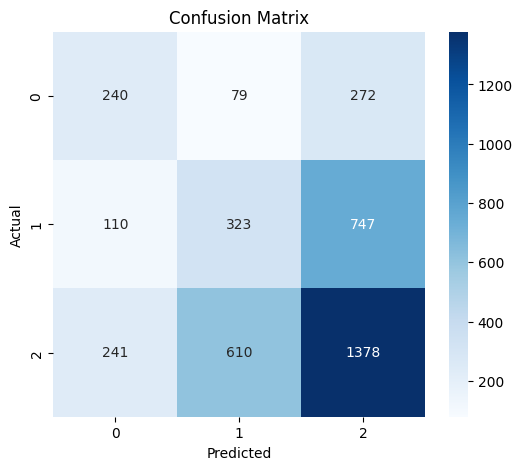

In [13]:
cm = confusion_matrix(
    y_test,
    prediction
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

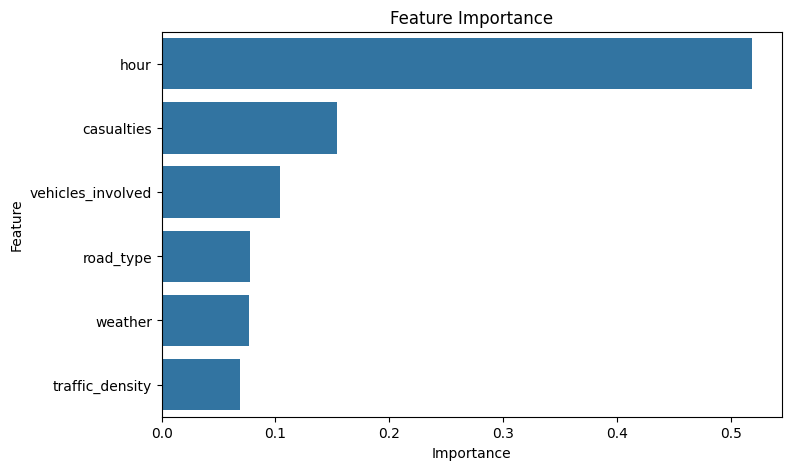

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [15]:
import joblib

joblib.dump(
    model,
    "road_accident_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
print("Task 4 Completed Successfully")

Task 4 Completed Successfully
